# Stable Diffusion 文生图推理实战

本 Notebook 提供一个完整的文生图（Text-to-Image）推理流程，基于 HuggingFace `diffusers` 库与 ModelScope 平台实现。

功能包括：
- 使用 ModelScope `snapshot_download()` 将预训练 Stable Diffusion 模型权重下载并缓存到本地（`cache_dir` 指定目录）
- 从本地缓存路径加载 Stable Diffusion Pipeline，根据文本 prompt 生成图像
- 使用 `matplotlib` 内联显示生成结果

## 一、导入依赖库

### 1.1 `diffusers` 库简介与环境检测

**`diffusers`** 是由 🤗 HuggingFace 开源的扩散模型工具库，提供了一整套用于推理和训练扩散模型的模块化组件。

**核心功能：**
- **预训练模型接口**：通过 `from_pretrained()` 一键加载 Stable Diffusion、DALL·E、Imagen 等主流扩散模型。
- **Pipeline 封装**：`StableDiffusionPipeline` 等高阶 Pipeline 类将 VAE、U-Net、Text Encoder、Scheduler 等子组件统一封装，开箱即用。
- **Scheduler（噪声调度器）**：内置 DDPM、DDIM、PNDM、DPM-Solver 等多种采样算法，可灵活替换以平衡速度与质量。
- **模型组件化**：VAE、U-Net、文本编码器等均可单独访问和替换，方便研究者自定义实验。
- **内存优化工具**：提供 `enable_vae_slicing()`、`enable_model_cpu_offload()` 等显存节省策略，支持低显存 GPU 运行大模型。

**与本 Notebook 的关系：**  
本 Notebook 使用 `StableDiffusionPipeline` 实现文本到图像的生成，并借助 `diffusers` 提供的组件访问接口打印模型子结构。

> 官方文档：https://huggingface.co/docs/diffusers  
> GitHub：https://github.com/huggingface/diffusers

In [1]:
import importlib       # 导入 importlib 标准库，用于动态检测指定包是否已安装（importlib.util.find_spec 返回 ModuleSpec 对象或 None）
import subprocess      # 导入 subprocess 标准库，用于在 Notebook 内部调用系统命令（此处用于执行 pip install）
import sys             # 导入 sys 标准库，用于获取当前 Python 解释器路径（sys.executable），确保 pip 与当前 kernel 一致

def check_and_install(package_name: str, import_name: str = None) -> None:
    """
    检查指定 Python 包是否已安装，若未安装则通过 pip 自动安装。

    参数:
        package_name (str): pip 安装时使用的包名（如 'diffusers'），用于 pip install 命令。
        import_name (str): 包在 Python 中的导入名（如有差异时指定，默认与 package_name 相同）。
                           例如 pip 包名为 'Pillow'，但导入名为 'PIL'。
    """
    import_name = import_name or package_name                  # 若未单独指定导入名，则默认与 pip 包名相同
    spec = importlib.util.find_spec(import_name)               # 查找包的模块规格；返回 ModuleSpec 对象表示已安装，返回 None 表示未安装
    if spec is None:                                           # spec 为 None 说明当前 Python 环境中找不到该包
        print(f"未检测到 '{package_name}'，正在自动安装...")  # 提示用户当前缺少该包，即将触发安装
        subprocess.check_call(                                 # 调用系统命令执行 pip install，check_call 在命令失败时抛出 CalledProcessError
            [sys.executable, "-m", "pip", "install", package_name],  # 使用当前 Notebook kernel 对应的 Python 解释器调用 pip，避免安装到错误环境
            stdout=subprocess.DEVNULL,                         # 屏蔽 pip 的标准输出（进度条等），保持 Notebook 输出整洁
            stderr=subprocess.STDOUT                           # 将 stderr 重定向到 stdout（同样屏蔽），错误信息由 check_call 的异常捕获
        )
        print(f"'{package_name}' 安装完成。")                 # 安装成功后打印确认信息
    else:
        print(f"'{package_name}' 已安装，版本路径: {spec.origin}")  # 包已存在时打印其 .py/.so 文件路径，便于确认安装位置

        
# 【torch 需单独安装，不在此处自动处理】
#   原因：pip 默认只能安装 CPU 版 torch，GPU 版需指定与本机 CUDA 版本匹配的安装源。
#   安装命令示例（以 CUDA 13.2 为例）：
#     pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu132
#   安装命令生成器（根据系统自动推荐）：https://pytorch.org/get-started/locally/
#   验证安装：import torch; print(torch.cuda.is_available())  # 输出 True 表示 GPU 可用


# 【diffusers 安装不会影响已有的 torch】
#   pip 安装 diffusers 时会检查 torch 版本是否满足其最低要求：
#   - 若已安装的 torch 满足要求 → 直接跳过，不动 torch
#   - 若 torch 版本过低 → pip 会升级 torch 至满足要求的最低版本（虚拟环境中可安全操作）
#   - 若 torch 未安装 → pip 自动安装 CPU 版 torch（不含 CUDA 支持，需手动重装 GPU 版）
#   因此，只要先正确安装好 GPU 版 torch，再安装 diffusers 就不会产生冲突。

# -------- 检查并安装本 Notebook 所需的核心依赖 --------
check_and_install("modelscope")                                # 检查 ModelScope SDK（阿里巴巴魔搭平台，提供国内高速模型下载）
check_and_install("matplotlib")                                # 检查 matplotlib 绘图库（用于在 Notebook 中内联显示生成的图像）
check_and_install("diffusers")                                 # 检查 HuggingFace diffusers 库（核心依赖，提供 StableDiffusionPipeline 等）
check_and_install("transformers")                              # 检查 transformers 库（diffusers 运行时依赖，提供 CLIP 文本编码器等组件）
check_and_install("accelerate")                                # 检查 accelerate 库（diffusers 推荐依赖，用于跨设备加速和模型 offload）
check_and_install("Pillow", import_name="PIL")                 # 检查 Pillow 图像库（pip 包名为 Pillow，导入名为 PIL，用于处理生成的图像）

'modelscope' 已安装，版本路径: d:\Python 3.14\Lib\site-packages\modelscope\__init__.py
'matplotlib' 已安装，版本路径: d:\Python 3.14\Lib\site-packages\matplotlib\__init__.py
'diffusers' 已安装，版本路径: d:\Python 3.14\Lib\site-packages\diffusers\__init__.py
'transformers' 已安装，版本路径: d:\Python 3.14\Lib\site-packages\transformers\__init__.py
'accelerate' 已安装，版本路径: d:\Python 3.14\Lib\site-packages\accelerate\__init__.py
'Pillow' 已安装，版本路径: d:\Python 3.14\Lib\site-packages\PIL\__init__.py


In [2]:
import torch                                    # 导入 PyTorch 深度学习框架，提供张量运算和 CUDA 设备检测
from modelscope import snapshot_download       # 从 ModelScope SDK 导入模型快照下载函数，返回本地缓存目录的绝对路径（str）
from diffusers import StableDiffusionPipeline  # 从 HuggingFace diffusers 库导入 SD Pipeline，支持从本地路径加载
from PIL import Image                          # 导入 PIL（Pillow）图像库，用于处理和保存生成的 PIL Image 对象
import matplotlib.pyplot as plt               # 导入 matplotlib 绘图模块，用于在 Notebook 中内联显示生成图像
import os                                      # 导入 os 模块，用于路径处理（os.path.abspath）和目录创建

## 二、文本生成图像函数（`generate_image_from_text`）

封装完整的文生图流程：加载模型 → 可选打印结构 → 可选保存权重 → 生成图像 → 保存文件。

**支持的模型（ModelScope 版本，按系列分类）：**

> 本 Notebook 使用 `modelscope.snapshot_download()` 下载模型，以下为 ModelScope 平台上的模型 ID。  
> SD 1.x 系列由 `AI-ModelScope` 组织镜像发布；SD 2.x / SDXL 由 `stabilityai` 官方账号直接发布。

| 系列 | ModelScope 模型 ID | 分辨率 | 文本编码器 | 显存（float16） | 所需 Pipeline | ModelScope 访问 | 说明 |
|---|---|---|---|---|---|---|---|
| **SD 1.x** | `AI-ModelScope/stable-diffusion-v1-4` | 512×512 | CLIP ViT-L/14 | ~4 GB | `StableDiffusionPipeline` | ✅ 无需登录 | 最早公开版，AI-ModelScope 镜像，**入门首选** |
| **SD 1.x** | `AI-ModelScope/stable-diffusion-v1-5` | 512×512 | CLIP ViT-L/14 | ~4 GB | `StableDiffusionPipeline` | ✅ 无需登录 | v1.4 改进版，AI-ModelScope 镜像，**LoRA/ControlNet 资源最多** |
| **SD 2.x** | `stabilityai/stable-diffusion-2-1-base` | 512×512 | OpenCLIP ViT-H/14 | ~5 GB | `StableDiffusionPipeline` | ✅ 无需登录 | 官方账号发布，比 HF 更易获取，与 v1.x 插件不兼容 |
| **SD 2.x** | `stabilityai/stable-diffusion-2-1` | 768×768 | OpenCLIP ViT-H/14 | ~6 GB | `StableDiffusionPipeline` | ✅ 无需登录 | 官方账号发布，768×768 高分辨率，细节更丰富，**当前默认** |
| **SDXL** | `stabilityai/stable-diffusion-xl-base-1.0` | 1024×1024 | 双 CLIP | ~8 GB | `StableDiffusionXLPipeline` | ✅ 无需登录 | 参数量为 v1.5 的 3 倍，**官方最强开源版** |
| **SDXL** | `stabilityai/stable-diffusion-xl-refiner-1.0` | 1024×1024 | 双 CLIP | ~8 GB | `StableDiffusionXLImg2ImgPipeline` | ✅ 无需登录 | 配合 SDXL base 输出做二次精修，专门用于 img2img 细化 |
| **SD 3.x** | `stabilityai/stable-diffusion-3-medium` | 1024×1024 | T5-XXL + 双 CLIP | ~10 GB | `StableDiffusion3Pipeline` | ⚠️ 需注册登录 | 全新 MMDiT 架构（非 U-Net），文字渲染大幅提升 |
| **SD 3.x** | `stabilityai/stable-diffusion-3.5-large` | 1024×1024 | T5-XXL + 双 CLIP | ~12 GB | `StableDiffusion3Pipeline` | ⚠️ 需注册登录 | SD3 升级版，当前效果最强 |

> **ModelScope 访问说明：**
> - ✅ **无需登录**：直接调用 `snapshot_download(model_id)` 即可下载，无需账号
> - ⚠️ **需注册登录**：需注册 [modelscope.cn](https://modelscope.cn) 账号（支持手机号/微信）并在代码中设置 Token：  
>   `os.environ["MODELSCOPE_API_TOKEN"] = "your_token"` 或命令行执行 `modelscope login --token your_token`
>
> **Pipeline 说明：**
> - `StableDiffusionPipeline`：适用于 SD 1.x / 2.x，即本 Notebook 当前使用的 Pipeline
> - `StableDiffusionXLPipeline`：SDXL 文生图专用，与 SD 1.x/2.x 的 Pipeline **不可混用**
> - `StableDiffusionXLImg2ImgPipeline`：SDXL refiner 专用，接收 base 输出的 latent 做精修，而非直接文生图
> - `StableDiffusion3Pipeline`：SD 3.x 专用，底层架构为 MMDiT（多模态扩散 Transformer），完全不同于前两代

In [3]:
def generate_image_from_text(
    prompt: str,
    output_path: str = "generated_image.png",
    model_path: str = "./model_cache/SD",
    device: str = "cuda",
    num_inference_steps: int = 50,
    guidance_scale: float = 7.5,
    print_model_structure: bool = False,
    save_model_weights: bool = False,
    weights_dir: str = "model_weights"
):
    """
    使用 Stable Diffusion Pipeline 根据文本提示生成图像并保存到本地。
    模型需提前通过 download_model_weights() 下载，将其返回的本地路径传入 model_path。

    参数:
        prompt (str): 文本提示，用自然语言描述要生成的图像内容，推荐使用英文以获得最佳效果。
        output_path (str): 生成图像的保存路径（含文件名），支持 PNG/JPEG 等格式，
                           默认为当前工作目录下的 'generated_image.png'。
        model_path (str): 本地模型目录路径，即 download_model_weights() 的返回值（str 类型绝对路径）。
                          该目录需包含 diffusers 格式的模型文件（config.json、model_index.json 等）。
                          注意：本函数使用 StableDiffusionPipeline，仅兼容 SD 1.x / 2.x 系列；
                                SDXL 需用 StableDiffusionXLPipeline，SD 3.x 需用 StableDiffusion3Pipeline。
        device (str): 计算设备，'cuda' 使用 GPU（推荐），'cpu' 使用 CPU（速度极慢）。
                      若 CUDA 不可用会自动切换到 CPU。
        num_inference_steps (int): 去噪迭代步数，步数越多图像质量越高但耗时越长，通常 20~50 步效果良好，默认 50。
        guidance_scale (float): 分类器自由引导（CFG）强度，控制生成图像与文本提示的贴合程度。
                                值越大越贴近 prompt 但多样性降低，值越小越自由但可能偏离 prompt，
                                通常取 5~15，默认 7.5。
        print_model_structure (bool): 是否打印模型各子组件的网络结构（VAE、U-Net 等）。
        save_model_weights (bool): 是否将完整模型权重额外保存到 weights_dir 目录（save_pretrained 平铺格式）。
        weights_dir (str): save_model_weights=True 时的权重保存目录路径。
    """
    print(f"开始生成图像，提示: '{prompt}'")               # 打印当前图像生成的文本提示，便于追踪
    print(f"从本地路径加载模型: {model_path}")             # 打印模型的本地路径，确认加载来源

    if device == "cuda" and not torch.cuda.is_available():  # 检查 CUDA 是否可用：若指定 cuda 但 CUDA 不可用，则自动降级
        print("CUDA 不可用，切换到 CPU，生成过程可能会非常缓慢")  # 提示用户当前环境不支持 GPU 加速
        device = "cpu"                                      # 将设备切换为 CPU，避免后续 CUDA 调用报错

    print(f"使用设备: {device}")                           # 打印最终使用的计算设备（cuda 或 cpu）

    try:
        pipe_args = {}                                       # 初始化 Pipeline 构造参数字典，根据设备动态添加参数
        if device == "cuda":                                 # 当使用 GPU 时，启用 float16 半精度以节省显存、加速推理
            pipe_args["torch_dtype"] = torch.float16        # float16 在 GPU 上比 float32 快约 2 倍，显存占用减半

        print("正在加载模型...")                            # 提示模型加载开始（模型已在本地，无需下载）
        pipe = StableDiffusionPipeline.from_pretrained(model_path, **pipe_args)  # 从本地目录加载 SD Pipeline，model_path 为 download_model_weights() 返回的绝对路径
        pipe = pipe.to(device)                               # 将 Pipeline 所有模型参数和缓冲区迁移到指定设备（GPU/CPU）
        print("模型加载完成。")                             # 确认模型加载成功

        if save_model_weights:                               # 若用户请求保存权重，则将完整 Pipeline 序列化到本地目录
            print(f"正在保存模型权重到 {weights_dir} 目录...")  # 提示当前正在执行权重保存操作
            os.makedirs(weights_dir, exist_ok=True)          # 创建权重保存目录，exist_ok=True 表示目录已存在时不报错
            pipe.save_pretrained(weights_dir)                # 将 Pipeline 所有组件的权重和配置文件保存到目录
            print(f"模型权重已保存到 {os.path.abspath(weights_dir)}")  # 打印权重保存的绝对路径，便于用户定位文件

        if print_model_structure:                            # 若用户请求打印模型结构，则遍历各子组件并打印
            print("\n--- 开始打印 Stable Diffusion 模型结构 ---")  # 模型结构打印区域的分隔标题

            if hasattr(pipe, 'vae') and pipe.vae is not None:  # 检查 Pipeline 是否包含 VAE 组件
                print("\n1. VAE (Variational Autoencoder) 结构:")  # 打印 VAE 模块标题
                print(pipe.vae)                              # 打印 VAE（AutoencoderKL）的完整网络结构树
            else:
                print("\n1. VAE: 未加载或不可用")          # VAE 不存在时的提示信息

            if hasattr(pipe, 'text_encoder') and pipe.text_encoder is not None:  # 检查是否包含文本编码器组件
                print("\n2. Text Encoder 结构:")           # 打印文本编码器标题
                print(pipe.text_encoder)                     # 打印 CLIPTextModel 的完整网络结构树
            else:
                print("\n2. Text Encoder: 未加载或不可用") # 文本编码器不存在时的提示信息

            if hasattr(pipe, 'tokenizer') and pipe.tokenizer is not None:  # 检查是否包含分词器组件
                print("\n3. Tokenizer 信息:")             # 打印分词器标题
                print(pipe.tokenizer)                        # 打印 CLIPTokenizer 的配置信息（非 nn.Module，打印配置字典）
            else:
                print("\n3. Tokenizer: 未加载或不可用")   # 分词器不存在时的提示信息

            if hasattr(pipe, 'unet') and pipe.unet is not None:  # 检查是否包含 U-Net 组件
                print("\n4. U-Net 结构:")                 # 打印 U-Net 标题
                print(pipe.unet)                             # 打印 UNet2DConditionModel 的完整网络结构树
            else:
                print("\n4. U-Net: 未加载或不可用")       # U-Net 不存在时的提示信息

            if hasattr(pipe, 'scheduler') and pipe.scheduler is not None:  # 检查是否包含噪声调度器组件
                print("\n5. Scheduler 信息:")             # 打印调度器标题
                print(pipe.scheduler)                        # 打印调度器（如 PNDMScheduler）的配置信息
            else:
                print("\n5. Scheduler: 未加载或不可用")   # 调度器不存在时的提示信息

            if hasattr(pipe, 'safety_checker') and pipe.safety_checker is not None:  # 检查是否包含安全审核组件（SD 1.x 默认包含）
                print("\n6. Safety Checker 结构:")        # 打印安全审核器标题
                print(pipe.safety_checker)                   # 打印 Safety Checker 的网络结构
            else:
                print("\n6. Safety Checker: 未加载或不可用")  # 安全审核器不存在时的提示信息（SD 2.x 不包含）

            if hasattr(pipe, 'feature_extractor') and pipe.feature_extractor is not None:  # 检查是否包含特征提取器（通常配合 Safety Checker 使用）
                print("\n7. Feature Extractor（通常配合 Safety Checker）信息:")  # 打印特征提取器标题
                print(pipe.feature_extractor)                # 打印特征提取器（CLIPFeatureExtractor）配置信息
            else:
                print("\n7. Feature Extractor: 未加载或不可用")  # 特征提取器不存在时的提示信息

            print("\n--- 模型结构打印结束 ---\n")         # 模型结构打印区域的结束分隔符

        print("开始生成图像...")                            # 提示图像生成阶段开始
        with torch.no_grad():                                # 关闭梯度追踪，推理阶段不需要反向传播，节省显存和计算
            image = pipe(prompt, num_inference_steps=num_inference_steps, guidance_scale=guidance_scale).images[0]  # 调用 Pipeline 生成图像：num_inference_steps 步去噪，guidance_scale 控制文本引导强度
                                                             # .images[0] 取结果列表的第一张图，类型为 PIL.Image.Image

        print("图像生成完成。")                             # 确认图像生成成功

        image.save(output_path)                              # 将 PIL Image 保存到指定路径，格式由文件扩展名自动判断（如 .png/.jpg）
        print(f"图像已保存到: {output_path}")              # 打印图像保存路径，便于用户定位文件

    except Exception as e:                                   # 捕获所有异常，进行友好的错误提示
        print(f"生成图像或打印模型结构时出现错误: {e}")    # 打印异常信息，帮助定位问题
        if "out of memory" in str(e).lower():               # 判断是否为 OOM（显存不足）错误
            print("显存不足（Out of Memory），建议尝试以下方法:")  # OOM 错误提示标题
            print("1. 确认其他进程已释放 GPU，通过 CUDA_VISIBLE_DEVICES 指定正确 GPU")  # 建议 1：释放其他占用显存的进程
            print("2. 使用更小的模型（如 SD v1.4 等）")    # 建议 2：使用参数量更小的模型
            print("3. 减小图像生成尺寸（若 pipeline 支持 width/height 参数）")  # 建议 3：降低生成分辨率
            print("4. 确保 GPU 推理时使用 torch_dtype=torch.float16")  # 建议 4：使用半精度减少显存占用
            print("5. 启用 'pipe.enable_vae_slicing()' 或 'pipe.enable_model_cpu_offload()'")  # 建议 5：使用 diffusers 提供的显存节省功能
            print("6. 关闭其他占用大量内存的程序")         # 建议 6：释放系统内存
            print("7. 若使用 CPU，确保有足够的系统 RAM")   # 建议 7：CPU 推理需要大量内存（通常 >16GB）
        elif "requires a GPU" in str(e).lower() and device == "cpu":  # 判断是否为模型不支持 CPU 的错误
            print("模型可能只能在 GPU 上运行，请检查文档，考虑使用其他模型。")  # 提示用户切换到 GPU 或更换模型

## 三、模型权重下载函数（`download_model_weights`）

独立的权重下载工具函数，仅下载并保存权重到本地，不执行图像生成。
适用于离线环境准备或一次性预下载模型文件。

In [4]:
def download_model_weights(
    model_id: str = "stabilityai/stable-diffusion-2-1",
    weights_dir: str = "./model_cache/SD"
):
    """
    从 ModelScope 平台下载模型权重到本地目录，不执行图像生成。
    使用国内镜像，速度远快于直连 HuggingFace Hub，适合首次下载或离线环境准备。

    参数:
        model_id (str): ModelScope 平台上的模型 ID，与 HuggingFace 相同格式（organization/model-name）。
                        常用选项（按显存需求从低到高排列，均可在 ModelScope 无障碍下载）：
                        - 'AI-ModelScope/stable-diffusion-v1-4'           SD 1.x，~4GB，最早公开版，入门首选
                        - 'AI-ModelScope/stable-diffusion-v1-5'           SD 1.x，~4GB，社区资源最丰富
                        - 'stabilityai/stable-diffusion-2-1-base'         SD 2.x，~5GB，512×512
                        - 'stabilityai/stable-diffusion-2-1'              SD 2.x，~6GB，768×768（当前默认）
                        - 'stabilityai/stable-diffusion-xl-base-1.0'      SDXL，~8GB，1024×1024，官方最强开源版
        weights_dir (str): 模型本地缓存根目录，ModelScope 会在此目录下自动创建子目录结构存放模型文件。
                           返回的本地路径可直接传入 StableDiffusionPipeline.from_pretrained() 加载。
    返回:
        local_dir (str): 模型文件的本地绝对路径，可直接用于 from_pretrained(local_dir) 加载。
    """
    print(f"开始从 ModelScope 下载模型 {model_id} ...")    # 提示下载开始，打印模型 ID 供追踪

    try:
        local_dir = snapshot_download(                       # 从 ModelScope 下载模型快照到本地，返回值为模型文件的本地绝对路径（str）
            model_id,                                        # ModelScope 模型 ID，首次调用时自动下载所有权重和配置文件
            cache_dir=weights_dir                            # 指定本地缓存根目录，ModelScope 自动管理子目录结构
        )                                                    # local_dir: str，下载完成后的模型本地路径
        print(f"模型已成功下载到: {local_dir}")             # 打印成功信息和模型文件的本地绝对路径
        return local_dir                                     # 返回本地路径，调用方可直接用于 from_pretrained(local_dir)
    except Exception as e:                                   # 捕获下载过程中的所有异常
        print(f"下载模型权重时出现错误: {e}")              # 打印异常信息，常见原因：网络超时、模型 ID 错误、磁盘空间不足

## 四、参数配置与执行

配置生成参数并执行图像生成任务。

**关键参数说明：**
- `num_inference_steps=50`：去噪步数，步数越多图像质量越高但耗时越长，通常 20~50 步效果良好
- `guidance_scale=7.5`：分类器自由引导（CFG）强度，值越大生成图像越贴近 prompt，但多样性降低（通常 5~15）

In [7]:
text_prompt = "A photo of an astronaut riding a horse on the moon."  # 文本提示：描述要生成图像的内容，英文提示通常效果优于中文

output_image_path = "SD_generated.png"                       # 生成图像的输出路径（相对于当前工作目录，即 Notebook 所在目录），格式由扩展名决定（.png 无损/.jpg 有损）

model_name = "stabilityai/stable-diffusion-2-1"              # ModelScope 上的 SD 2.1，768×768 高分辨率，显存约 6GB，效果优于 v1.x

processing_device = "cuda"                                   # 计算设备："cuda" 使用 GPU（推荐），"cpu" 极慢不推荐

inference_steps = 50                                         # 去噪迭代步数：步数越多质量越高但耗时越长，通常 20~50 步效果良好

cfg_scale = 7.5                                              # CFG 引导强度：值越大越贴近 prompt 但多样性降低，通常取 5~15

should_print_structure = False                               # 是否打印模型结构：True 则在生成前打印各子组件网络结构

should_save_weights = False                                  # 是否保存模型权重：True 则将完整模型序列化到本地目录

model_weights_dir = "./model_cache/SD"                       # 权重保存目录名，将在当前工作目录下创建

local_model_path = download_model_weights(                   # 从 ModelScope 下载模型到本地，返回值为模型文件的本地绝对路径（str）
    model_id=model_name,                                     # ModelScope 模型 ID，首次调用时联网下载，后续直接返回缓存路径
    weights_dir=model_weights_dir                            # 本地缓存根目录，模型文件存放在其子目录中
)                                                            # local_model_path: str，可直接传入 generate_image_from_text 的 model_path 参数

generate_image_from_text(                                    # 调用文生图函数，使用已下载到本地的模型，不再联网
    prompt=text_prompt,                                      # 文本提示，描述要生成的图像内容
    output_path=output_image_path,                           # 生成图像的保存路径
    model_path=local_model_path,                             # 传入 download_model_weights 返回的本地路径，无需重复下载
    device=processing_device,                                # 推理设备：cuda（GPU）或 cpu
    num_inference_steps=inference_steps,                     # 去噪步数，控制生成质量与速度的平衡
    guidance_scale=cfg_scale,                                # CFG 引导强度，控制生成图像与文本提示的贴合程度
    print_model_structure=should_print_structure,            # 是否打印各子组件网络结构
    save_model_weights=should_save_weights,                  # 是否额外保存 save_pretrained 格式的权重
    weights_dir=model_weights_dir                            # save_pretrained 权重保存目录
)

# 以下为更多 prompt 示例（取消注释尝试不同风格）：
# generate_image_from_text('A futuristic cityscape at sunset, flying cars, neon lights, concept art', 'city.png', model_path=local_model_path, device=processing_device)
# generate_image_from_text('A hyperrealistic portrait of an old fisherman, weathered face, detailed skin texture', 'fisherman.png', model_path=local_model_path, device=processing_device)
# generate_image_from_text('An oil painting of a mystical forest with glowing mushrooms, fantasy art', 'forest.png', model_path=local_model_path, device=processing_device)

开始从 ModelScope 下载模型 stabilityai/stable-diffusion-2-1 ...


2026-07-20 17:14:01,975 | INFO    | modelscope_hub.download | Downloading 29 files from stabilityai/stable-diffusion-2-1@master


Downloading:   0%|          | 0/29 [00:00<?, ?file/s]

模型已成功下载到: model_cache\SD\models\stabilityai--stable-diffusion-2-1\snapshots\master
开始生成图像，提示: 'A photo of an astronaut riding a horse on the moon.'
从本地路径加载模型: model_cache\SD\models\stabilityai--stable-diffusion-2-1\snapshots\master
使用设备: cuda
正在加载模型...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

模型加载完成。
开始生成图像...


  0%|          | 0/50 [00:00<?, ?it/s]

图像生成完成。
图像已保存到: SD_generated.png


## 五、显示生成图像

使用 `matplotlib` 将生成的图像以内联方式显示在 Notebook 中，并打印图像基本信息。

图像路径  : c:\Users\15513\Desktop\MultimodalPractice\SD_generated.png
图像尺寸  : 768 × 768 像素
颜色模式  : RGB
文本提示  : A photo of an astronaut riding a horse on the moon.


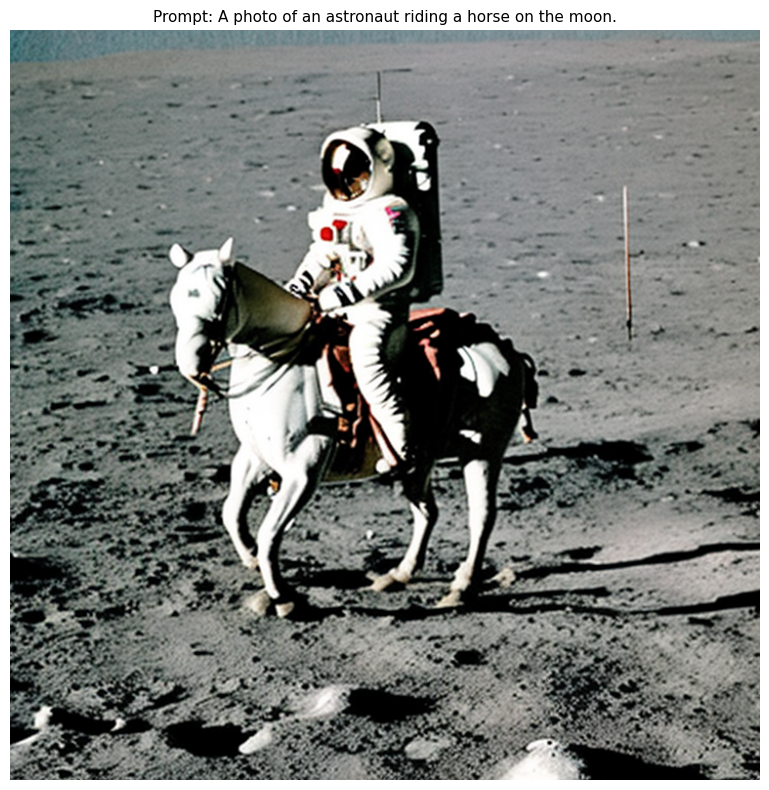

In [9]:
def show_generated_image(image_path: str, prompt: str = "") -> None:
    """
    从本地路径加载并用 matplotlib 内联显示生成的图像，同时打印图像基本信息。

    参数:
        image_path (str): 生成图像的本地文件路径（相对或绝对路径均可），支持 PNG/JPEG 等格式。
        prompt (str): 生成该图像时使用的文本提示，用于在图像标题中展示，默认为空字符串。
    """
    if not os.path.exists(image_path):                       # 检查图像文件是否存在，避免 FileNotFoundError
        print(f"图像文件不存在: {image_path}")              # 提示用户路径有误或图像尚未生成
        return                                               # 文件不存在时直接返回，不执行后续显示逻辑

    img = Image.open(image_path)                             # 用 PIL 打开图像文件，返回 PIL.Image.Image 对象，支持 PNG/JPEG 等格式

    print(f"图像路径  : {os.path.abspath(image_path)}")     # 打印图像的绝对路径，方便定位文件位置
    print(f"图像尺寸  : {img.size[0]} × {img.size[1]} 像素")  # img.size: tuple(width, height)，分别为宽和高（单位：像素）
    print(f"颜色模式  : {img.mode}")                        # img.mode: str，如 'RGB'（3 通道）、'RGBA'（含透明通道）、'L'（灰度）
    print(f"文本提示  : {prompt if prompt else '（未提供）'}")  # 打印生成该图像所用的 prompt，便于与图像内容对照

    fig, ax = plt.subplots(figsize=(8, 8))                   # 创建 Figure 和 Axes 对象；figsize=(8,8) 表示画布宽高均为 8 英寸，适合正方形图像
    ax.imshow(img)                                           # 将 PIL Image 渲染到 Axes 上；imshow 自动将像素值映射为颜色，RGB 模式直接显示彩色图
    ax.axis("off")                                           # 关闭坐标轴刻度和边框，使图像显示更干净
    ax.set_title(                                            # 设置图像标题，显示在图像上方
        f"Prompt: {prompt}" if prompt else "Generated Image",  # 有 prompt 时显示完整提示词，无则显示默认标题
        fontsize=11,                                         # 标题字体大小：11pt，适合较长的 prompt 文本
        wrap=True                                            # 允许标题文字自动换行，避免长 prompt 超出画布宽度
    )
    plt.tight_layout()                                       # 自动调整子图间距，防止标题与图像内容重叠
    plt.show()                                               # 在 Notebook 中内联渲染并显示图像


# -------- 调用显示函数 --------
# 注意：output_image_path 和 text_prompt 在第四章（Cell 10）的 if __name__ == "__main__" 块中定义。
# Jupyter Notebook 中 __name__ 始终为 '__main__'，该块执行后变量写入全局命名空间，此处可直接引用。
# 前提：必须先运行第四章 Cell 10 完成图像生成，再运行本 Cell，否则会抛出 NameError。
show_generated_image(
    image_path=output_image_path,                            # 图像路径：来自 Cell 10 的 output_image_path 变量（str），指向已生成的图像文件
    prompt=text_prompt                                       # 文本提示：来自 Cell 10 的 text_prompt 变量（str），显示在图像标题中
)